In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
path_c = '../../../combined_cannonical.tab'
path_ncl = '../../../combined_nc-ind.tab'
path_ncind = '../../../combined_nc-Leader.tab'
canonical = pd.read_csv(path_c, sep = "\t")
nc_leader = pd.read_csv(path_ncl, sep = "\t")
nc_ind = pd.read_csv(path_ncind, sep = "\t")

In [3]:
canon_artic = canonical[canonical['Source_File'].str.contains('artic_primer')]
canon_artic.head()
nc_leader_artic = nc_leader[nc_leader['Source_File'].str.contains('artic_primer')]
#nc_leader_artic.head()

In [4]:
canon_artic[['c_norm_ct', 'c_f_only', 'c_b_only', 'c_both', 'c_al_one']] = canon_artic["cluster_normalized_count"].str.extract('(.+)\\((.+),(.+),(.+),(.+)\\)')



C:\Users\exmar\AppData\Local\Temp\ipykernel_27488\2842542307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  canon_artic[['c_norm_ct', 'c_f_only', 'c_b_only', 'c_both', 'c_al_one']] = canon_artic["cluster_normalized_count"].str.extract('(.+)\\((.+),(.+),(.+),(.+)\\)')
C:\Users\exmar\AppData\Local\Temp\ipykernel_27488\2842542307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  canon_artic[['c_norm_ct', 'c_f_only', 'c_b_only', 'c_both', 'c_al_one']] = canon_artic["cluster_normalized_count"].str.extract

c:\Users\exmar\miniconda3\envs\challenge2025\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


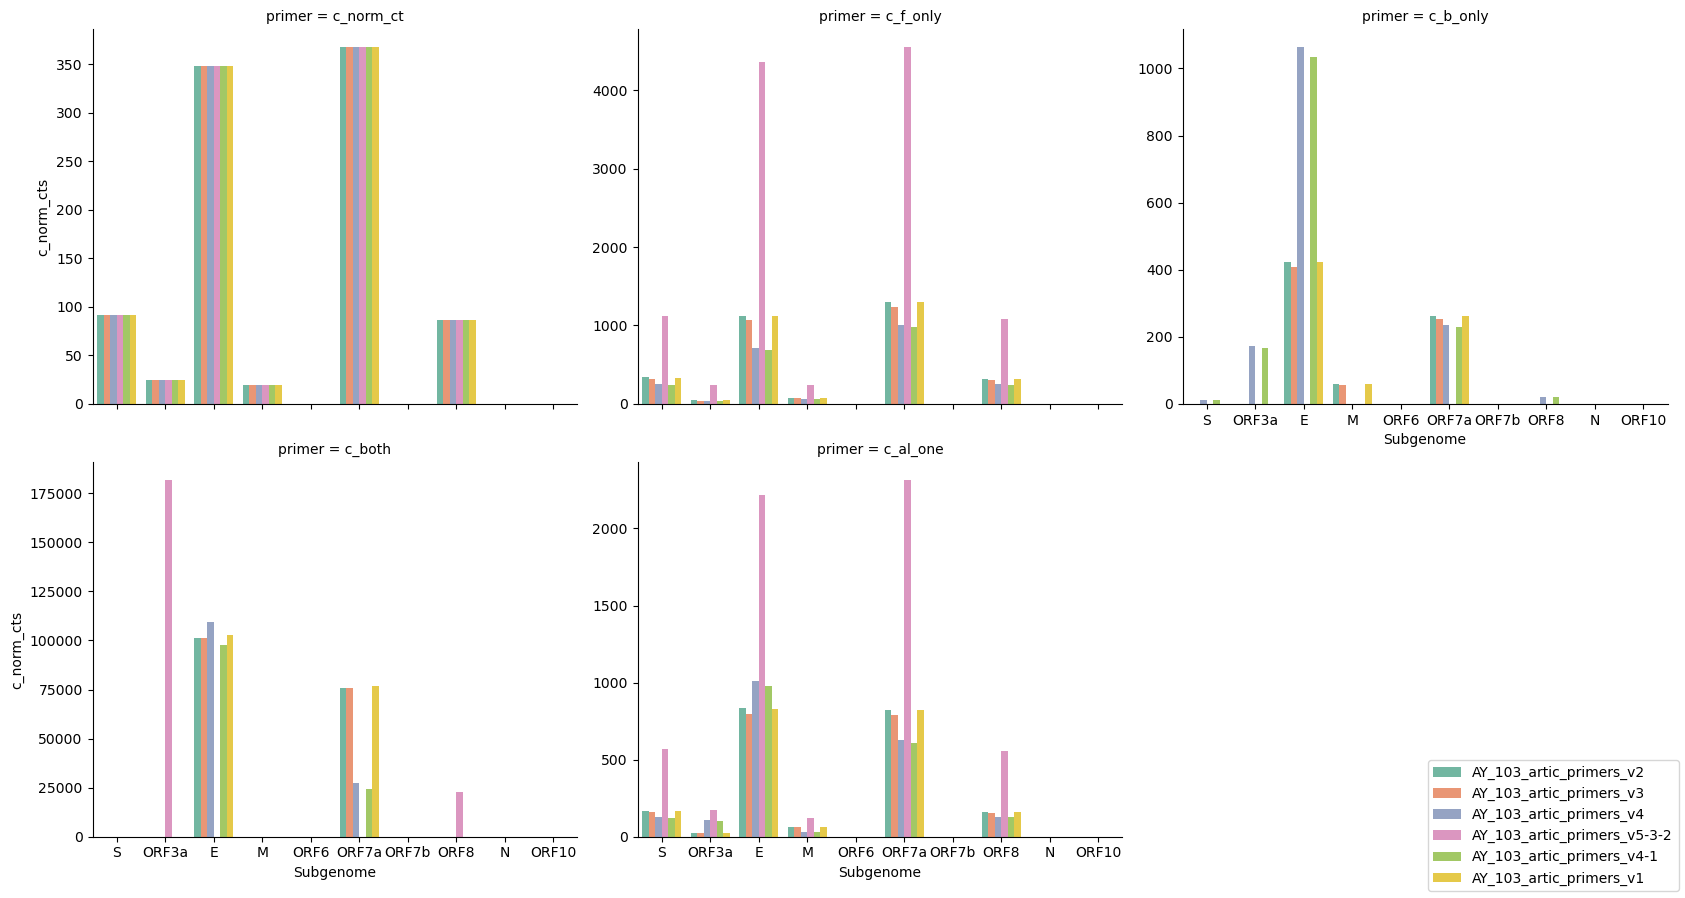

In [5]:
# Visualizing for beta
vis_data = pd.melt(canon_artic[canon_artic['Source_File'].str.contains('AY_103')], id_vars = ['Source_File', 'subgenome'],\
                   value_vars = ['c_norm_ct', 'c_f_only', 'c_b_only', 'c_both', 'c_al_one'], var_name = 'primer',
                   value_name = 'c_norm_cts')

vis_data['c_norm_cts'] = vis_data['c_norm_cts'].astype(float)

grid = sns.FacetGrid(vis_data, col="primer", col_wrap=3, height = 4.5, aspect =1.25, sharey=False, legend_out=False)
grid.map(sns.barplot, "subgenome", "c_norm_cts", data = vis_data, hue = 'Source_File', palette = 'Set2')
grid.set_xlabels("Subgenome")
grid.add_legend()
sns.move_legend(grid, "lower right")
plt.show()


C:\Users\exmar\AppData\Local\Temp\ipykernel_27488\3955413080.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vis_data2['c_norm_ct'] = vis_data2['c_norm_ct'].astype(float)


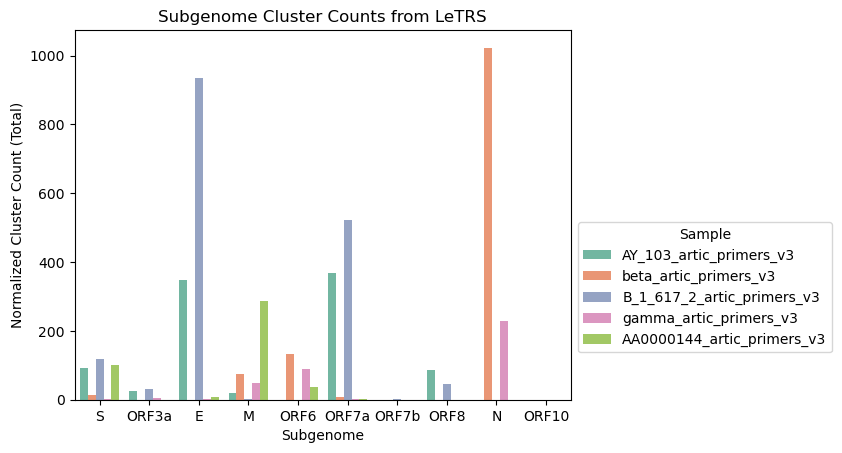

In [6]:
vis_data2 = canon_artic[canon_artic['Source_File'].str.contains('v3')]

vis_data2['c_norm_ct'] = vis_data2['c_norm_ct'].astype(float)

sns.barplot(data = vis_data2, x = 'subgenome', y = 'c_norm_ct', hue = 'Source_File', palette = 'Set2')
plt.xlabel("Subgenome")
plt.ylabel("Normalized Cluster Count (Total)")
plt.title("Subgenome Cluster Counts from LeTRS")
plt.legend(title = "Sample", bbox_to_anchor=(1, 0.5))
plt.show()

In [7]:
exclude = ["Sim_Data_FA_primer", "AA0000114", "AY_103_artic_primers_v1", "AY_103_artic_primers_v2", "AY_103_artic_primers_v4",\
           "AY_103_artic_primers_v4-1", "AY_103_artic_primers_v5-3-2", "B_1_617_2_artic_primers_v1", "B_1_617_2_artic_primers_v2",\
           "B_1_617_2_artic_primers_v4", "B_1_617_2_artic_primers_v4_1", "B_1_617_2_artic_primers_v5_3_2", "OG_Paper", "Simulated_Data_With_FA",\
            "beta_artic_primers_v1", "beta_artic_primers_v2", "beta_artic_primers_v4", "beta_artic_primers_v4-1", "beta_artic_primers_v5-3-2",\
            "gamma_artic_primers_v1", "gamma_artic_primers_v2", "gamma_artic_primers_v4", "gamma_artic_primers_v4-1", "gamma_artic_primers_v5-3-2",\
            "PRJNA1193019_Fasta", "ART_Nanopore_mode", "Sim_NCsgRNA", "Sim_Data_FA_articv3", "AA0000144_artic_primers_v1", "AA0000144_artic_primers_v2",\
            "AA0000144_artic_primers_v4", "AA0000144_artic_primers_v4-1", "AA0000144_artic_primers_v5-3-2", "Simulated_Data", "SD_ART", "AY_103_NC_cutoff_1",\
            "WT_Covid"]
canon_strains = canonical[~canonical['Source_File'].isin(exclude)]
canon_strains.loc[:,'Strain'] = canonical['Source_File'].case_when([(canonical['Source_File'].str.contains('omicron|ba_2'), 'Omicron'),\
                                                            (canonical['Source_File'].str.contains('beta'), 'Beta'),\
                                                            (canonical['Source_File'].str.contains('gamma'), 'Gamma'),\
                                                            (canonical['Source_File'].str.contains('delta|AY_103|B_1_617'), 'Delta'),
                                                            (canonical['Source_File'].str.contains('AA0000144|alpha'), 'Alpha'),\
                                                            (canonical['Source_File'].str.contains('b_1-0'), 'Wild Type'),\
                                                            (canonical['Source_File'].str.contains('PRJNA1193019'), 'Persistent Infection')])
canon_strains.loc[:,'c_norm_ct'] = canon_strains.loc[:,"cluster_normalized_count"].str.extract('(.+)\\(').astype(float)
canon_strains.loc[:,'c_ct'] = canon_strains.loc[:,"cluster_count"].str.extract('(.+)\\(').astype(float)
canon_strains = canon_strains.fillna(0)
canon_strains.head()
canon_strains.to_csv('./LeTRS_canonical_strain_res.csv', index = False)

C:\Users\exmar\AppData\Local\Temp\ipykernel_27488\3015378438.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  canon_strains.loc[:,'Strain'] = canonical['Source_File'].case_when([(canonical['Source_File'].str.contains('omicron|ba_2'), 'Omicron'),\
C:\Users\exmar\AppData\Local\Temp\ipykernel_27488\3015378438.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  canon_strains.loc[:,'c_norm_ct'] = canon_strains.loc[:,"cluster_normalized_count"].str.extract('(.+)\\(').astype(float)
C:\Users\exmar\AppData\Loca

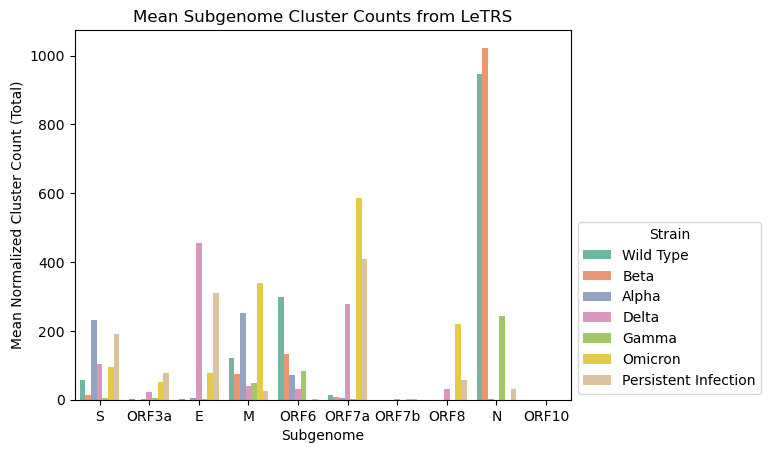

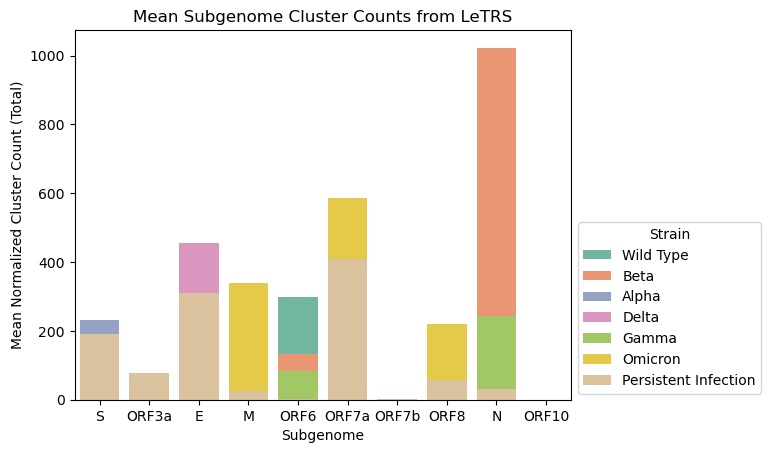

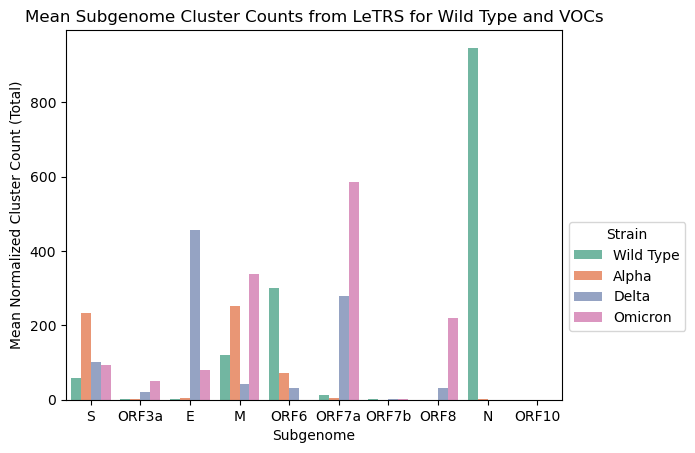

In [8]:
sns.barplot(data = canon_strains, x = 'subgenome', y = 'c_norm_ct', hue = 'Strain', palette = 'Set2', \
            errorbar = None, hue_order = ["Wild Type", "Beta", "Alpha", "Delta", "Gamma", "Omicron", "Persistent Infection"])
plt.xlabel("Subgenome")
plt.ylabel("Mean Normalized Cluster Count (Total)")
plt.title("Mean Subgenome Cluster Counts from LeTRS")
plt.legend(title = "Strain", bbox_to_anchor=(1, 0.5))
plt.show()

sns.barplot(data = canon_strains, x = 'subgenome', y = 'c_norm_ct', hue = 'Strain', palette = 'Set2', \
            errorbar = None, hue_order = ["Wild Type", "Beta", "Alpha", "Delta", "Gamma", "Omicron", "Persistent Infection"], \
                dodge = False)
plt.xlabel("Subgenome")
plt.ylabel("Mean Normalized Cluster Count (Total)")
plt.title("Mean Subgenome Cluster Counts from LeTRS")
plt.legend(title = "Strain", bbox_to_anchor=(1, 0.5))
plt.show()

sns.barplot(data = canon_strains[canon_strains['Strain'].isin(['Wild Type', 'Alpha', 'Delta', 'Omicron'])], x = 'subgenome', y = 'c_norm_ct', hue = 'Strain', palette = 'Set2', \
            errorbar = None, hue_order = ['Wild Type', 'Alpha', 'Delta', 'Omicron'])
plt.xlabel("Subgenome")
plt.ylabel("Mean Normalized Cluster Count (Total)")
plt.title("Mean Subgenome Cluster Counts from LeTRS for Wild Type and VOCs")
plt.legend(title = "Strain", bbox_to_anchor=(1, 0.5))
plt.show()

c:\Users\exmar\miniconda3\envs\challenge2025\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


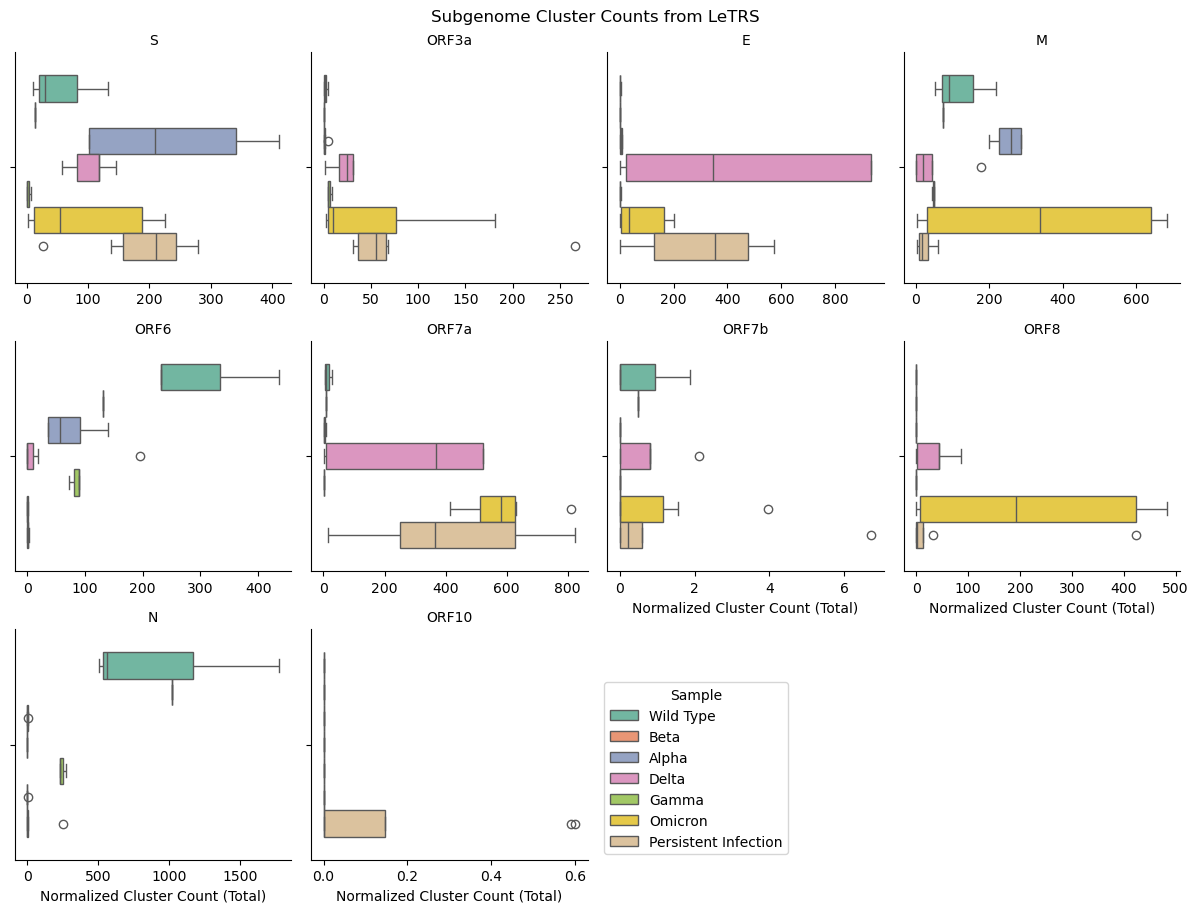

In [9]:
grid = sns.FacetGrid(canon_strains, col="subgenome", col_wrap = 4, sharex=False, legend_out=True)
grid.map(sns.boxplot, 'c_norm_ct', data = canon_strains, hue = 'Strain', palette = 'Set2', hue_order = ["Wild Type", "Beta", "Alpha", "Delta", "Gamma", "Omicron", "Persistent Infection"])
grid.set_xlabels("Subgenome")
grid.set_xlabels("Normalized Cluster Count (Total)")
grid.set_titles("{col_name}")
plt.suptitle("Subgenome Cluster Counts from LeTRS", y=1.01)
plt.legend(title = "Sample", bbox_to_anchor=(1.75, 0.8))
plt.show()

In [10]:
PI_data = canon_strains[canon_strains['Strain'] == 'Persistent Infection']
PI_data["Timepoint"] = PI_data['Source_File'].case_when([(PI_data['Source_File'].str.contains('SRR31567433'), 776),
                                                        (PI_data['Source_File'].str.contains('SRR31567434'), 776), # Throat swab
                                                        (PI_data['Source_File'].str.contains('SRR31567435'), 640),
                                                        (PI_data['Source_File'].str.contains('SRR31567436'), 630),
                                                        (PI_data['Source_File'].str.contains('SRR31567437'), 630), # Throat swab
                                                        (PI_data['Source_File'].str.contains('SRR31567438'), 522),
                                                        (PI_data['Source_File'].str.contains('SRR31567439'), 401),
                                                        (PI_data['Source_File'].str.contains('SRR31567440'), 312)])
PI_data['c_norm_ct'] = PI_data['c_norm_ct'].fillna(0)
PI_no_throat = PI_data[~PI_data['Source_File'].str.contains('SRR31567434|SRR31567437')]
PI_data.head()

C:\Users\exmar\AppData\Local\Temp\ipykernel_27488\1226621751.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PI_data["Timepoint"] = PI_data['Source_File'].case_when([(PI_data['Source_File'].str.contains('SRR31567433'), 776),
C:\Users\exmar\AppData\Local\Temp\ipykernel_27488\1226621751.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PI_data['c_norm_ct'] = PI_data['c_norm_ct'].fillna(0)


,subgenome,ref_leader_end,peak_leader_end,ref_TRS_start,peak_TRS_start,peak_count,peak_normalized_count,cluster_count,cluster_normalized_count,Source_File,Strain,c_norm_ct,c_ct,Timepoint
140,S,65,65,21552,21552,"460(68,7,0,75)","271.53(522.00,49.92,0.00,275.91)","473(69,8,0,77)","279.21(529.68,57.05,0.00,283.26)",PRJNA1193019_SRR31567439,Persistent Infection,279.21,473.0,401
141,ORF3a,69,69,25385,25385,"108(11,27,1,39)","63.75(84.44,192.55,746.83,143.47)","110(11,27,1,39)","64.93(84.44,192.55,746.83,143.47)",PRJNA1193019_SRR31567439,Persistent Infection,64.93,110.0,401
142,E,69,69,26237,26237,"777(103,178,34,315)","458.65(790.68,1269.39,25392.08,1158.80)","777(103,178,34,315)","458.65(790.68,1269.39,25392.08,1158.80)",PRJNA1193019_SRR31567439,Persistent Infection,458.65,777.0,401
143,M,65,65,26469,26469,"6(0,0,0,0)","3.54(0.00,0.00,0.00,0.00)","8(1,0,0,1)","4.72(7.68,0.00,0.00,3.68)",PRJNA1193019_SRR31567439,Persistent Infection,4.72,8.0,401
144,ORF6,69,69,27041,27041,"4(0,1,0,1)","2.36(0.00,7.13,0.00,3.68)","4(0,1,0,1)","2.36(0.00,7.13,0.00,3.68)",PRJNA1193019_SRR31567439,Persistent Infection,2.36,4.0,401


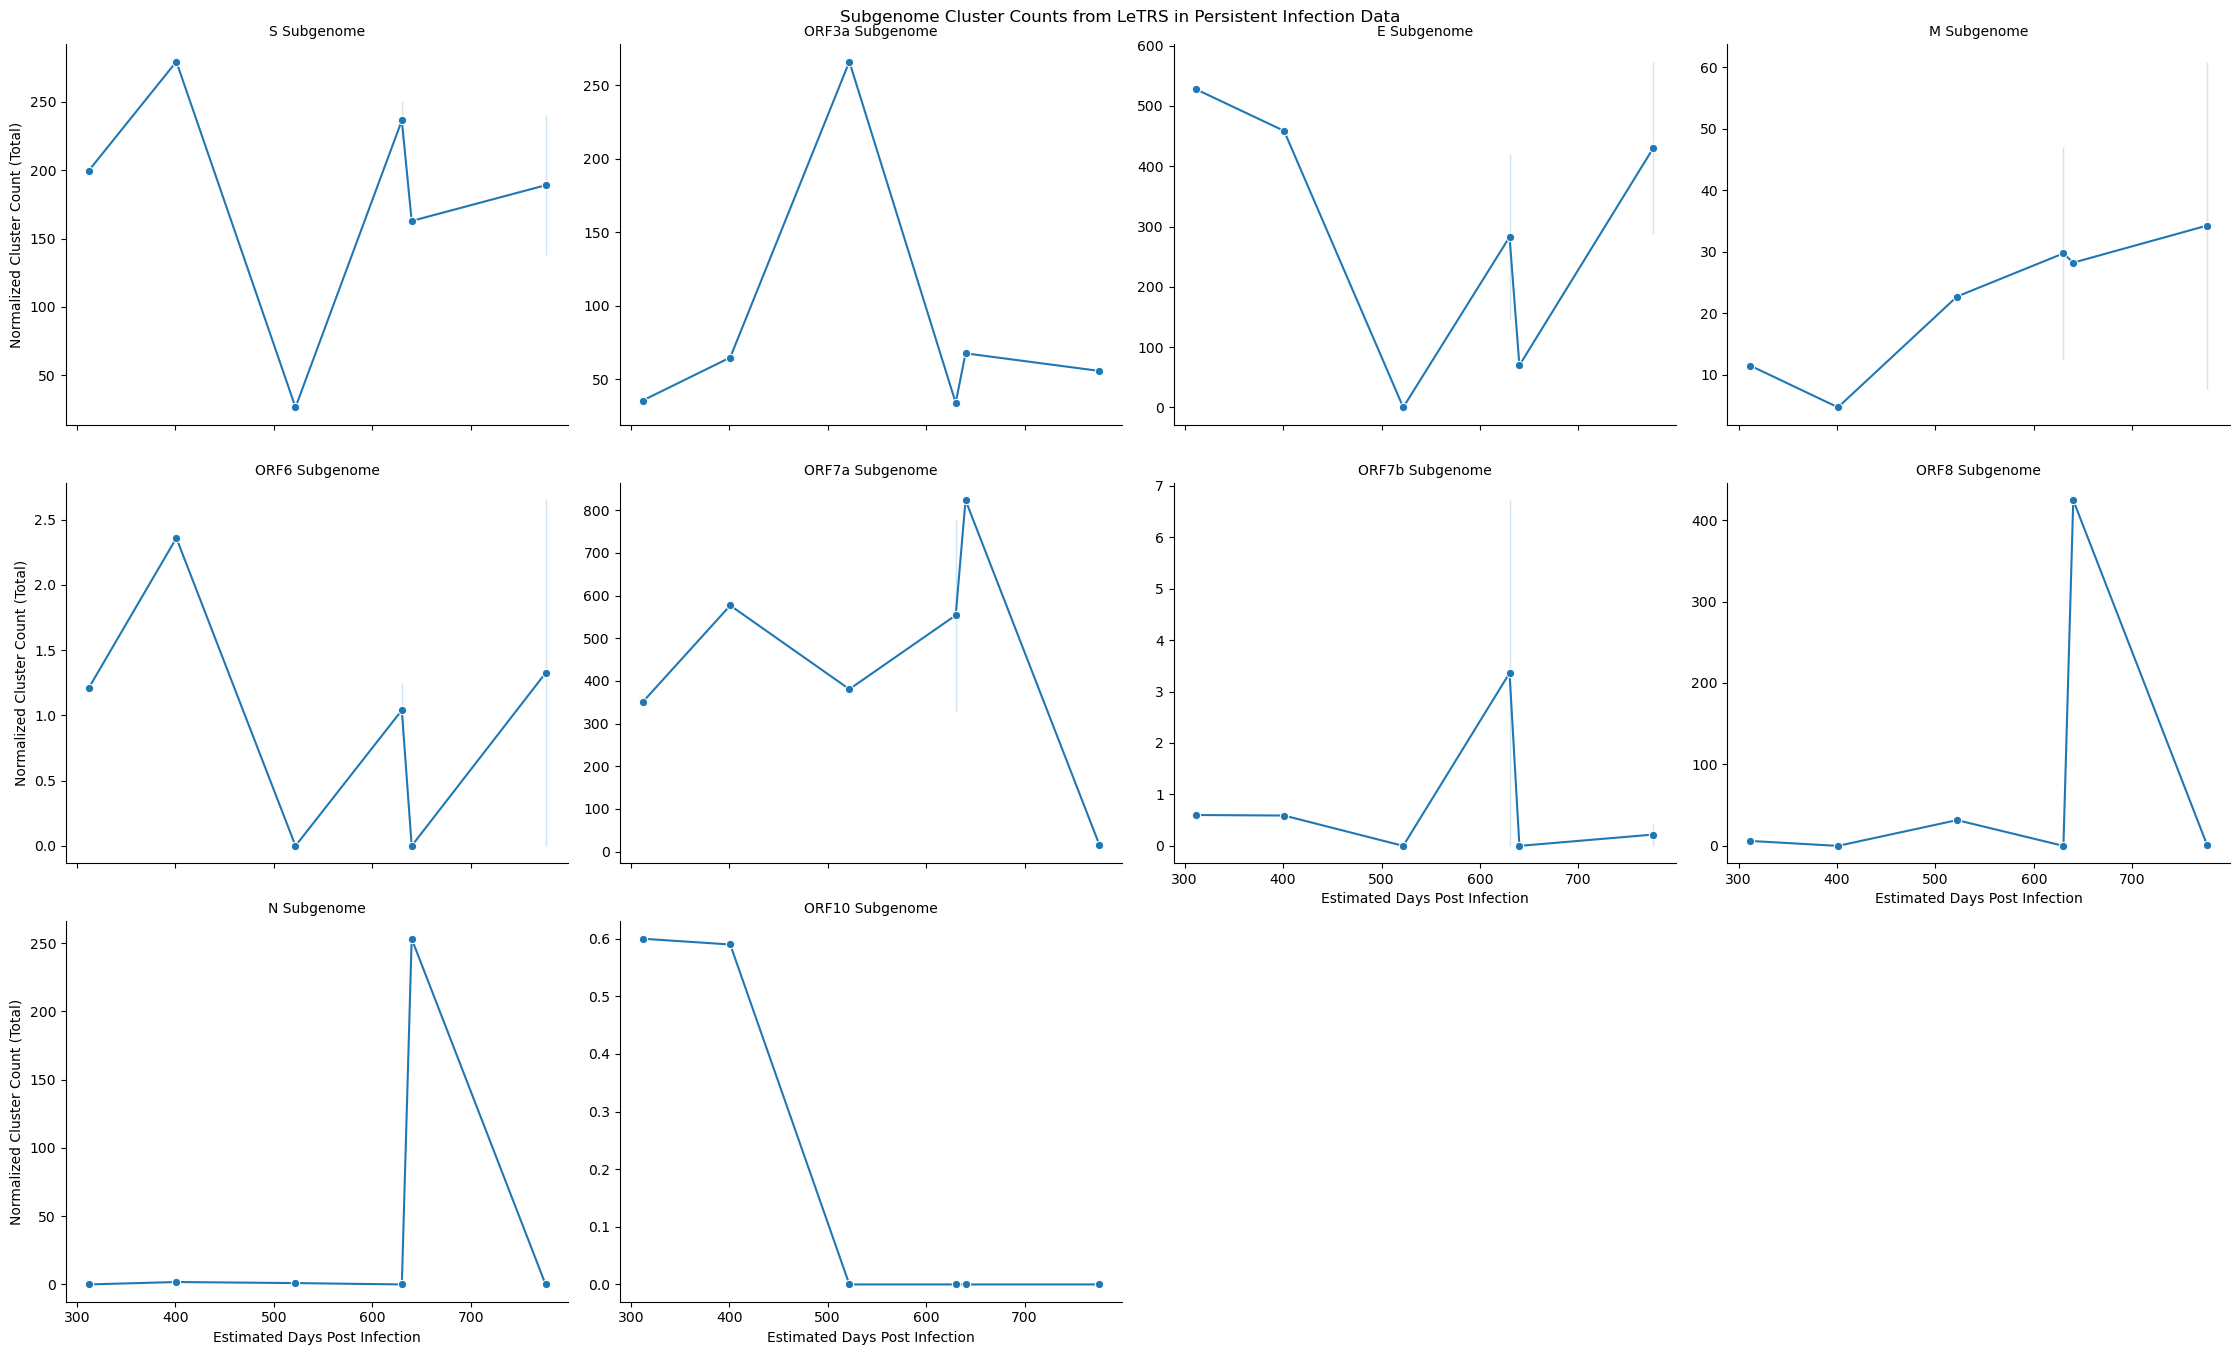

In [11]:
grid = sns.FacetGrid(PI_data, col="subgenome", height = 4.5, aspect =1.25, sharey=False, legend_out=True, col_wrap = 4)
grid.map(sns.lineplot, 'Timepoint', 'c_norm_ct', data = PI_no_throat, marker = 'o')
grid.set_xlabels("Estimated Days Post Infection")
grid.set_ylabels("Normalized Cluster Count (Total)")
grid.set_titles(col_template = "{col_name} Subgenome")
plt.suptitle("Subgenome Cluster Counts from LeTRS in Persistent Infection Data", y=1)
plt.show()

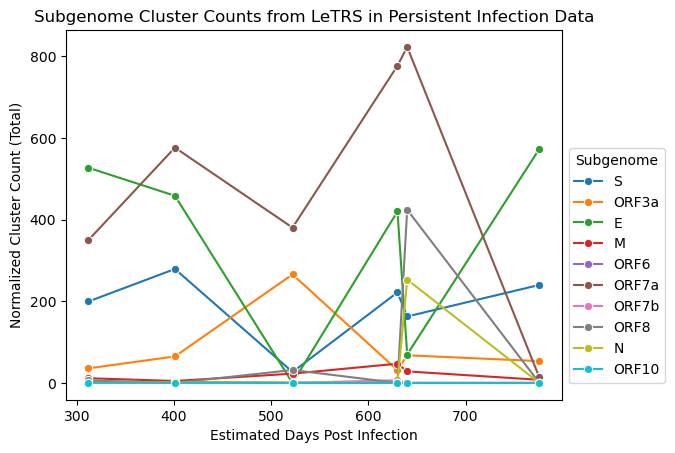

In [12]:
sns.lineplot(x = 'Timepoint', y ='c_norm_ct', data = PI_no_throat, hue = "subgenome", marker = 'o', \
             hue_order = ["S", "ORF3a", "E", "M", "ORF6", "ORF7a", "ORF7b", "ORF8", "N", "ORF10"])
plt.xlabel("Estimated Days Post Infection")
plt.ylabel("Normalized Cluster Count (Total)")
plt.title("Subgenome Cluster Counts from LeTRS in Persistent Infection Data", y=1)
plt.legend(title = "Subgenome", bbox_to_anchor=(1, 0.7))
plt.show()

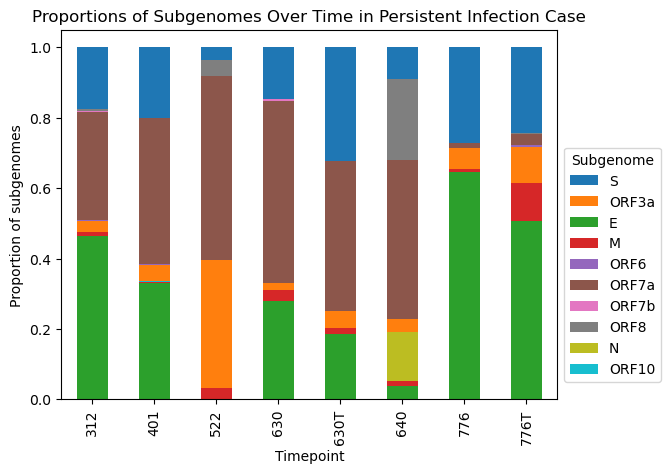

In [13]:
PI_throat_label = PI_data.copy()
PI_throat_label["Timepoint"] = PI_throat_label['Source_File'].case_when([(PI_data['Source_File'].str.contains('SRR31567433'), "776"),
                                                        (PI_data['Source_File'].str.contains('SRR31567434'), "776T"), # Throat swab
                                                        (PI_data['Source_File'].str.contains('SRR31567435'), "640"),
                                                        (PI_data['Source_File'].str.contains('SRR31567436'), "630"),
                                                        (PI_data['Source_File'].str.contains('SRR31567437'), "630T"), # Throat swab
                                                        (PI_data['Source_File'].str.contains('SRR31567438'), "522"),
                                                        (PI_data['Source_File'].str.contains('SRR31567439'), "401"),
                                                        (PI_data['Source_File'].str.contains('SRR31567440'), "312")])
prop_plot_data = PI_throat_label.copy()
#prop_plot_data.groupby(['Timepoint'])['subgenome'].value_counts(normalize = True).unstack('subgenome').plot.bar(stacked=True)
prop_plot_data = (PI_throat_label.groupby(['Timepoint','subgenome'])['c_norm_ct'].sum()/PI_throat_label.groupby(['Timepoint'])['c_norm_ct'].sum())
#prop_plot_data['proportions'] = prop_plot_data['c_norm_ct'] / prop_plot_data.groupby(['Timepoint'])['c_norm_ct'].transform('sum')
color_dict = {}
orfs = ["S", "ORF3a", "E", "M", "ORF6", "ORF7a", "ORF7b", "ORF8", "N", "ORF10"]
for o in range(len(orfs)):
    color_dict[orfs[o]] = sns.color_palette()[o]
prop_plot_data.unstack().plot.bar(color = color_dict, stacked=True)
idx = [9, 4, 0, 1, 5, 6, 7, 8, 2, 3]
handles, labels = plt.gca().get_legend_handles_labels()
reord_labels = [labels[i] for i in idx]
reord_handles = [handles[i] for i in idx]
plt.title('Proportions of Subgenomes Over Time in Persistent Infection Case')
plt.ylabel('Proportion of subgenomes')
plt.xlabel('Timepoint')
plt.legend(title = 'Subgenome', bbox_to_anchor=(1, 0.7), labels = reord_labels, handles = reord_handles)
plt.show()


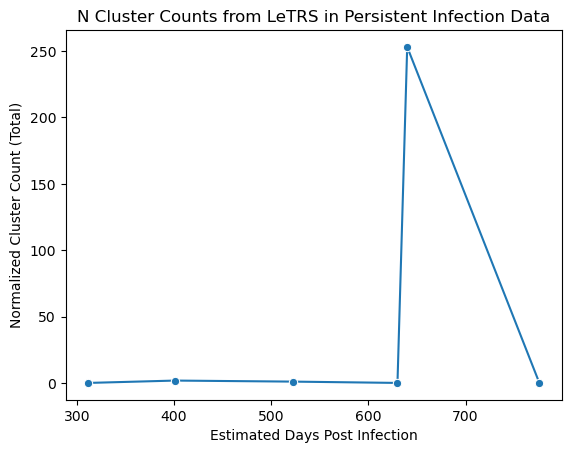

In [14]:
sns.lineplot(x = 'Timepoint', y ='c_norm_ct', data = PI_no_throat[PI_no_throat['subgenome']=='N'], marker = 'o')
plt.xlabel("Estimated Days Post Infection")
plt.ylabel("Normalized Cluster Count (Total)")
plt.title("N Cluster Counts from LeTRS in Persistent Infection Data", y=1)
plt.show()